# Documentación de Análisis: Clasificación de Alimentos mediante Machine Learning

Este cuaderno presenta un flujo de trabajo avanzado para la segmentación de aditivos alimentarios basándose en perfiles de riesgo toxicológico y nutricional, utilizando datos integrados de Open Food Facts y PubMed.

### 1. Configuración del Entorno y Librerías
El análisis utiliza el stack estándar de Python para ciencia de datos y aprendizaje no supervisado:
* **Tratamiento de datos**: `pandas` y `numpy`.
* **Visualización**: `matplotlib`, `seaborn` y `plotly.express` para gráficos interactivos.
* **Machine Learning (Scikit-Learn)**:
    * `StandardScaler`: Para normalizar las escalas de las variables de toxicidad.
    * `PCA`: Para reducción de dimensionalidad y visualización en 2D.
    * `KMeans`: Algoritmo principal de agrupamiento.
    * `silhouette_score`: Para validar la calidad de los clusters.

### 2. Preprocesamiento: Estandarización y PCA
Se aplica un análisis de **Componentes Principales (PCA)** sobre las dimensiones de riesgo (Cargas de Clase 0, 1 y 2) y el grado de procesamiento (NOVA):
* **Normalización**: Debido a que las cargas de aditivos pueden tener magnitudes muy diferentes, se utiliza `StandardScaler` para que ninguna variable domine injustamente el modelo.
* **Visualización de Dimensiones**: El Biplot de PCA permite observar cómo los aditivos se distribuyen en el espacio. Las flechas rojas (vectores de carga) indican qué riesgos científicos "empujan" a los aditivos hacia zonas de mayor peligro en el mapa.

### 3. Optimización del Agrupamiento (K-Means)
Para determinar la estructura óptima de los grupos, se utilizan dos técnicas:
* **Método del Codo (Elbow Method)**: Evalúa la reducción de la inercia (error cuadrático interno) a medida que aumenta el número de clusters ($K$). Ayuda a identificar el "punto de ruptura" donde añadir más grupos no aporta una mejora significativa.
* **Análisis de Silhouette**: Mide qué tan cerca está cada punto de su propio cluster en comparación con los demás. Un valor promedio alto (cercano a 1) indica que el agrupamiento es natural y los grupos están bien separados.

### 4. Perfilado de Clusters (Heatmap)
Tras ejecutar K-Means, se genera un **Mapa de Calor** basado en las medias de cada variable por cluster:
* **Diagnóstico de Riesgo**: Permite etiquetar los grupos según su perfil (ej: "Aditivos Críticos", "Uso Seguro", "Falsos Amigos").
* **Relación NOVA-Química**: El mapa revela correlaciones importantes, como el hecho de que productos altamente procesados (NOVA 4) suelen concentrar una mayor carga de aditivos Clase 2 (riesgo alto).

### 5. Generación de la Taxonomía Final
Finalmente, el cuaderno exporta una **Taxonomía de Riesgo** vinculada a los identificadores originales (`codigo_e`, `id` de Open Food Facts)[cite: 1, 4]. Esto permite que el análisis científico basado en PubMed se aplique directamente a la base de datos de productos reales, facilitando la identificación de alimentos problemáticos para el consumidor final.

In [20]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos y visualización
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Machine Learning: Preprocesamiento y Reducción de dimensiones
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Machine Learning: Clustering y Evaluación
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import joblib
import os

### 3. Optimización del Agrupamiento (K-Means)
Para determinar la estructura óptima de los grupos, se utilizan dos técnicas:
* **Método del Codo (Elbow Method)**: Evalúa la reducción de la inercia (error cuadrático interno) a medida que aumenta el número de clusters ($K$). Ayuda a identificar el "punto de ruptura" donde añadir más grupos no aporta una mejora significativa.
* **Análisis de Silhouette**: Mide qué tan cerca está cada punto de su propio cluster en comparación con los demás. Un valor promedio alto (cercano a 1) indica que el agrupamiento es natural y los grupos están bien separados.

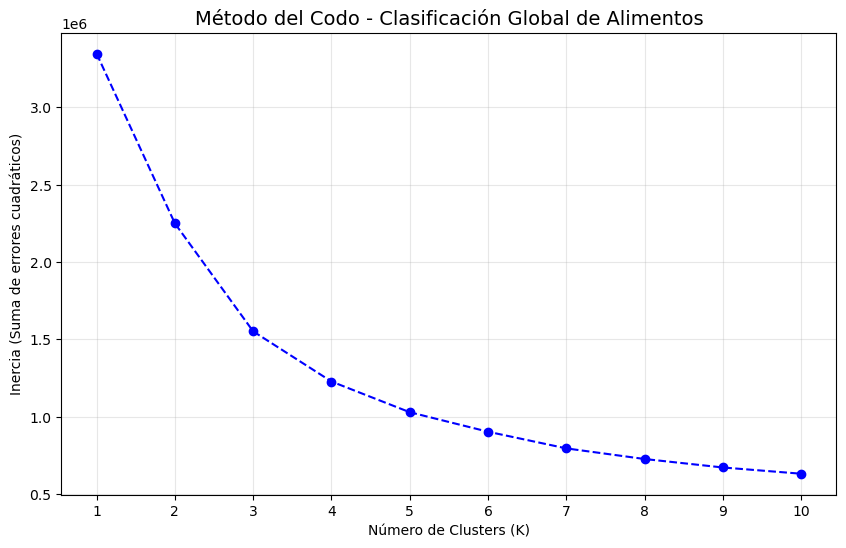

Inercia para K=2: 2249550.71
Inercia para K=3: 1551713.19
Inercia para K=4: 1227528.57
Inercia para K=5: 1029119.44


In [3]:
# 1. Cargar el dataset de alimentos procesado (el que unifica 800k registros)
df_final = pd.read_csv('../data/dataset_alimentos_quimica_nutricion.csv')

# 2. Seleccionar las características maestras para el clustering
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1']
X = df_final[features]

# 3. Preprocesamiento: Estandarización
# Nivelamos el peso de todas las variables para que el modelo no se sesgue por las magnitudes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Calcular la inercia para el Método del Codo (Elbow Method)
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 5. Visualización del Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo - Clasificación Global de Alimentos', fontsize=14)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de errores cuadráticos)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/food_products/metodo_codo_alimentos.png')
plt.show()

# 6. Salida de datos para análisis técnico
print(f"Inercia para K=2: {inertia[1]:.2f}")
print(f"Inercia para K=3: {inertia[2]:.2f}")
print(f"Inercia para K=4: {inertia[3]:.2f}")
print(f"Inercia para K=5: {inertia[4]:.2f}")

Para K = 3, el promedio de silhouette es: 0.3707


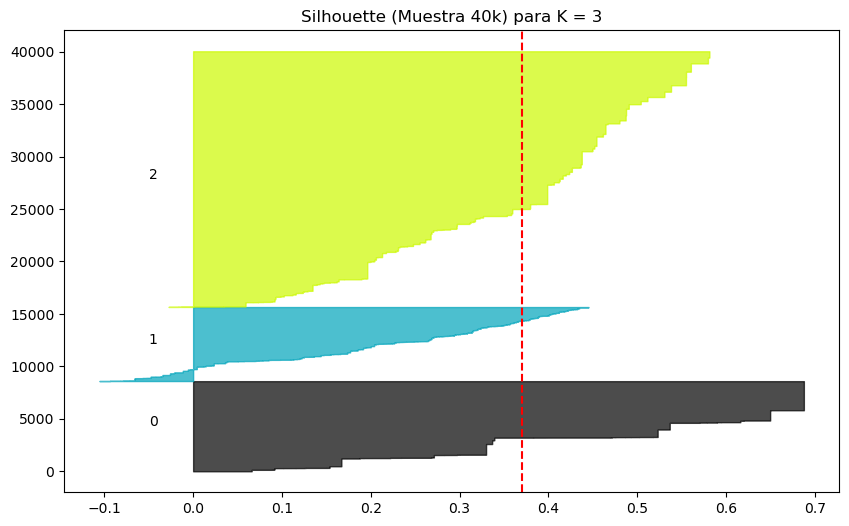

Para K = 4, el promedio de silhouette es: 0.3471


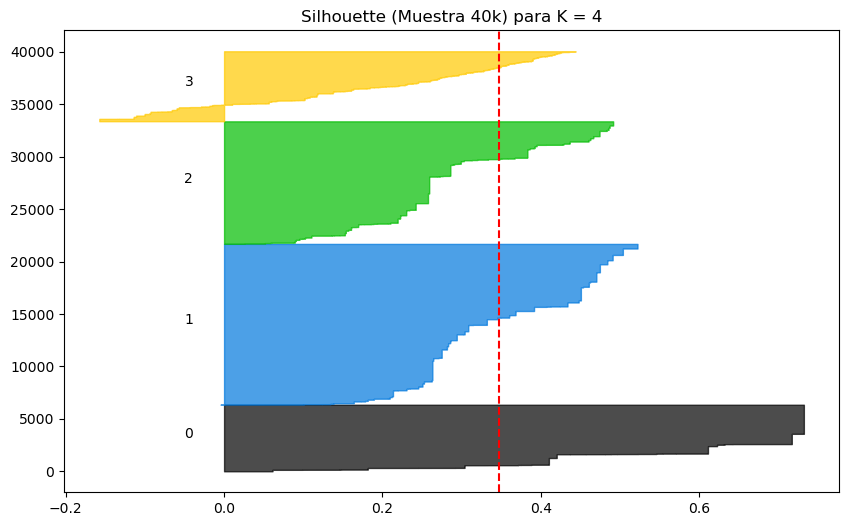

In [4]:
# 1. Cargar y estandarizar

df_sample = df_final.sample(n=40000, random_state=42)
X_sample = StandardScaler().fit_transform(df_sample[features])

for n_clusters in [3, 4]:
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 6)

    # Entrenamos el auditor solo con la muestra
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_sample)

    silhouette_avg = silhouette_score(X_sample, cluster_labels)
    print(f"Para K = {n_clusters}, el promedio de silhouette es: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_sample, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, 
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title(f"Silhouette (Muestra 40k) para K = {n_clusters}")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.savefig(f'../outputs/plots/food_products/silhouette_{n_clusters}_clusters.png')
    plt.show()

### 4. Perfilado de Clusters (Heatmap)
Tras ejecutar K-Means, se genera un **Mapa de Calor** basado en las medias de cada variable por cluster:
* **Diagnóstico de Riesgo**: Permite etiquetar los grupos según su perfil (ej: "Aditivos Críticos", "Uso Seguro", "Falsos Amigos").
* **Relación NOVA-Química**: El mapa revela correlaciones importantes, como el hecho de que productos altamente procesados (NOVA 4) suelen concentrar una mayor carga de aditivos Clase 2 (riesgo alto).

✅ [INFO] 'scaler_alimentos.pkl' y 'kmeans_alimentos.pkl' guardados en ../models/


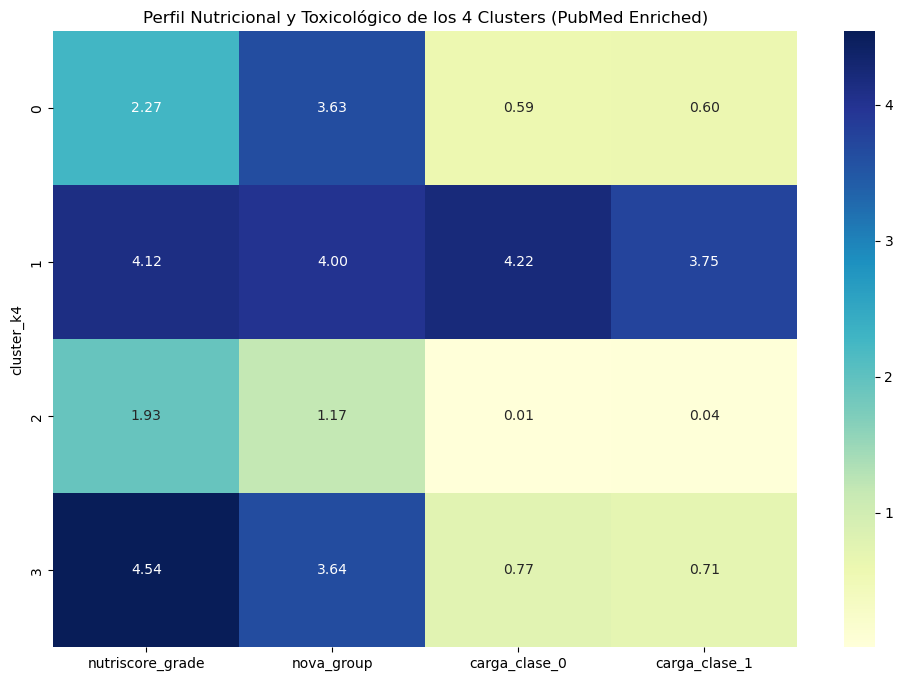

            nutriscore_grade  nova_group  carga_clase_0  carga_clase_1
cluster_k4                                                            
0                       2.27        3.63           0.59           0.60
1                       4.12        4.00           4.22           3.75
2                       1.93        1.17           0.01           0.04
3                       4.54        3.64           0.77           0.71


In [22]:
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Selección de variables y escalado
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1']
X = df_final[features].fillna(0) # Por si quedó algún nulo

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Ejecutar K-Means con la K ganadora (4)
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster_k4'] = kmeans_4.fit_predict(X_scaled)

# 3. Generar la tabla de medias
tabla_medias_k4 = df_final.groupby('cluster_k4')[features].mean().round(2)

# ==============================================================================
# NUEVO: EXPORTACIÓN DE LOS PICKLES PARA EL PIPELINE DE STREAMLIT
# ==============================================================================
# Creamos la carpeta models si no existe
os.makedirs('../models/', exist_ok=True)

# Guardamos el escalador y el modelo K-Means entrenado con las variables exactas
joblib.dump(scaler, '../models/scaler_alimentos.pkl')
joblib.dump(kmeans_4, '../models/kmeans_alimentos.pkl')
print("✅ [INFO] 'scaler_alimentos.pkl' y 'kmeans_alimentos.pkl' guardados en ../models/")
# ==============================================================================

# 4. Visualización para el informe
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_medias_k4, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Perfil Nutricional y Toxicológico de los 4 Clusters (PubMed Enriched)')
plt.savefig('../../outputs/plots/food_products/matriz.png')
plt.show()

print(tabla_medias_k4)

In [8]:
# 1. Comprobación rápida: ¿Hay datos en las columnas de carga?
print("Suma de cargas antes del heatmap:")
print(df_final[['carga_clase_0', 'carga_clase_1']].sum())

# 2. Si el paso anterior da números grandes, el problema es el escalado.
# Si el paso anterior da 0, es que el DataFrame se ha 'reseteado' y hay que volver a correr
# el bloque de 'Vinculación directa por nombre de columna' que funcionó antes.

Suma de cargas antes del heatmap:
carga_clase_0    1002682
carga_clase_1     920836
dtype: int64


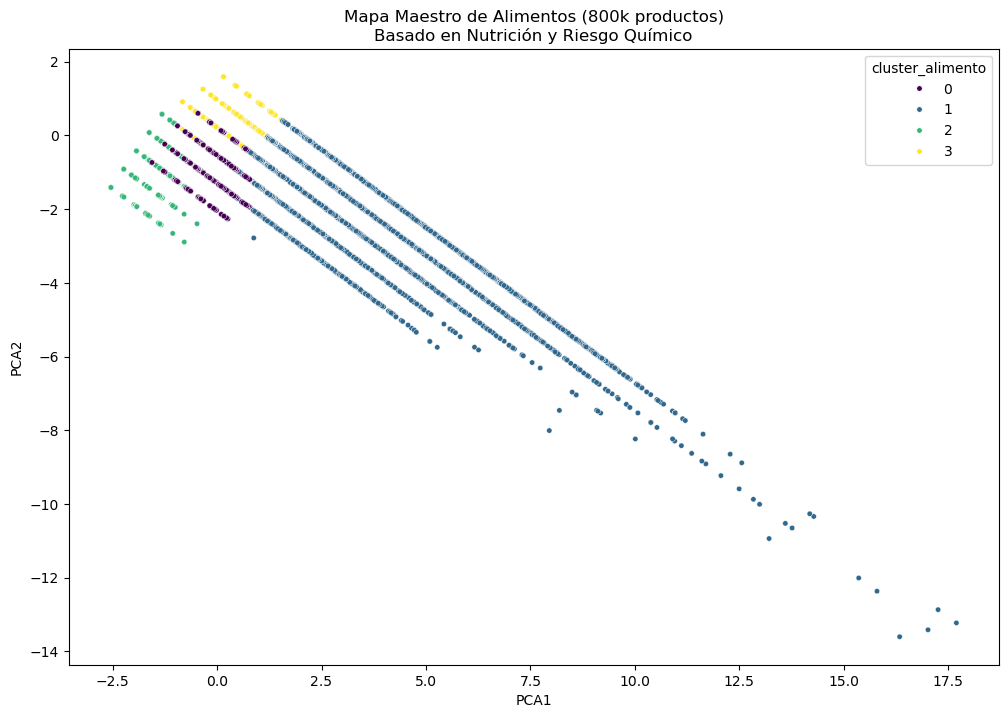

TABLA DE PERFILADO:
                  nutriscore_grade  nova_group  carga_clase_0  carga_clase_1
cluster_alimento                                                            
0                         2.268743    3.629404       0.593777       0.603401
1                         4.124981    3.997912       4.223551       3.746469
2                         1.932950    1.172381       0.014002       0.044771
3                         4.536500    3.643747       0.766564       0.707008


In [10]:
# 1. Preparar datos finales
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1']
X_scaled = StandardScaler().fit_transform(df_final[features])

# 2. Ejecutar K-Means con el K=4 que elegimos
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster_alimento'] = kmeans.fit_predict(X_scaled)

# 3. PCA para visualizar la "geografía" del mercado
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df_final['PCA1'] = pca_res[:, 0]
df_final['PCA2'] = pca_res[:, 1]

plt.figure(figsize=(12, 8))
# Usamos un alpha bajo porque hay 800k puntos y se solaparán
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_alimento', data=df_final, 
                palette='viridis', alpha=1, s=15)

plt.title('Mapa Maestro de Alimentos (800k productos)\nBasado en Nutrición y Riesgo Químico')
plt.savefig('../outputs/plots/food_products/PCA_final_alimentos.png')
plt.show()

# 4. EXPLICACIÓN DE LOS GRUPOS 
perfil = df_final.groupby('cluster_alimento')[features].mean()
print("TABLA DE PERFILADO:")
print(perfil)

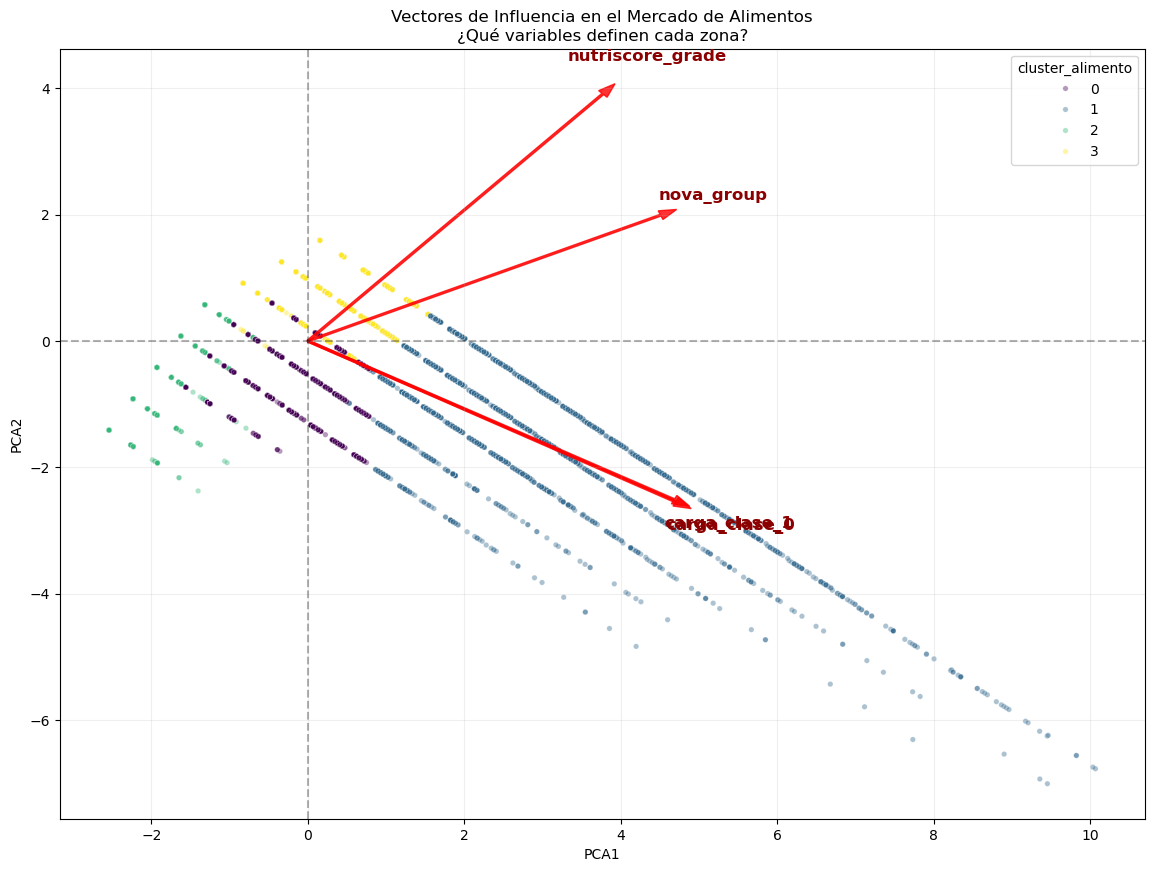

In [11]:
#Obtener los loadings (la importancia de cada variable en los ejes PCA)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(14, 10))

# Dibujamos los puntos (usamos una muestra de 50k para que las flechas resalten)
df_plot = df_final.sample(n=50000, random_state=42)
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster_alimento', data=df_plot, 
                palette='viridis', alpha=0.4, s=15)

#Añadir las flechas (Vectores)
# Ajustamos scale_factor para que las flechas tengan un tamaño legible en el gráfico
scale_factor = 6 

for i, feature in enumerate(features):
    # Dibujar la flecha
    plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
              color='red', alpha=0.8, width=0.03, head_width=0.15)
    
    # Añadir el nombre de la variable
    plt.text(loadings[i, 0] * scale_factor * 1.15, loadings[i, 1] * scale_factor * 1.15, 
             feature, color='darkred', ha='center', va='center', fontweight='bold', fontsize=12)

plt.title('Vectores de Influencia en el Mercado de Alimentos\n¿Qué variables definen cada zona?')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(alpha=0.2)
plt.savefig('../outputs/plots/food_products/PCA_vectores_alimentos.png')
plt.show()

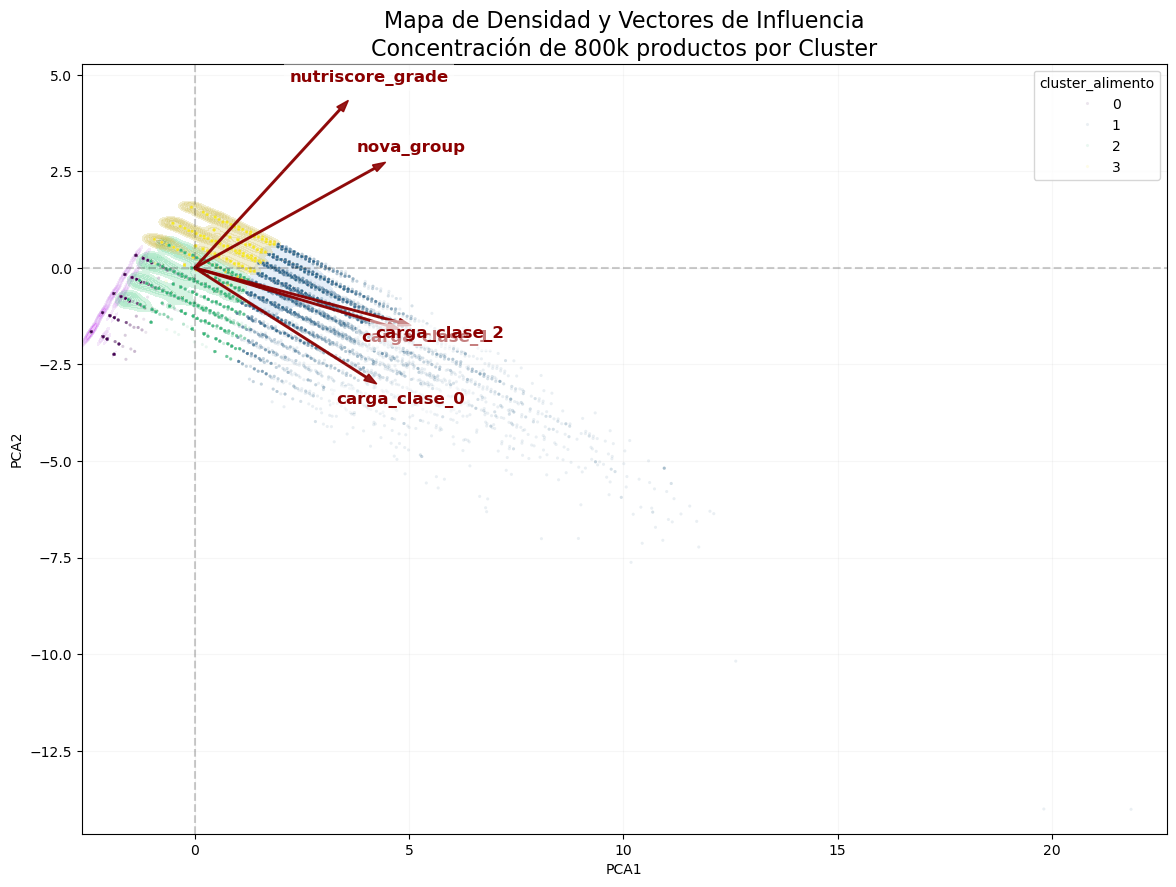

In [ ]:
# 1. Configuración del lienzo
plt.figure(figsize=(14, 10))

# 2. Dibujar la densidad (el gradiente de transparencia)
# Usamos una muestra mayor (100k) para que el gradiente sea preciso pero rápido
df_density = df_final.sample(n=100000, random_state=42)

# El truco: kdeplot con niveles de transparencia
sns.kdeplot(
    data=df_density, x='PCA1', y='PCA2', 
    hue='cluster_alimento', palette='viridis',
    fill=True, alpha=0.3, levels=10, thresh=0.05,
    legend=False
)

# 3. Dibujamos los puntos con alpha muy bajo para dar textura sin tapar
sns.scatterplot(
    x='PCA1', y='PCA2', hue='cluster_alimento', data=df_density, 
    palette='viridis', alpha=0.1, s=5, legend='full'
)

# 4. Añadir las flechas (Loadings del PCA)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
scale_factor = 6 

for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
              color='darkred', alpha=0.9, width=0.04, head_width=0.2)
    
    plt.text(loadings[i, 0] * scale_factor * 1.2, loadings[i, 1] * scale_factor * 1.2, 
             feature, color='darkred', ha='center', va='center', 
             fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# 5. Estética final
plt.title('Mapa de Densidad y Vectores de Influencia\nConcentración de 800k productos por Cluster', fontsize=16)
plt.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.axvline(0, color='black', linestyle='--', alpha=0.2)
plt.grid(alpha=0.1)
plt.savefig('../outputs/plots/food_products/PCA_vectores_densidad_alimentos.png')
plt.show()

In [ ]:
# 1. Preparar datos y escalado
features = ['nutriscore_grade', 'nova_group', 'carga_clase_0', 'carga_clase_1', 'carga_clase_2']
X_scaled = StandardScaler().fit_transform(df_final[features])

# 2. PCA para 3 componentes
pca = PCA(n_components=3)
pca_res = pca.fit_transform(X_scaled)
df_final['PCA1'] = pca_res[:, 0]
df_final['PCA2'] = pca_res[:, 1]
df_final['PCA3'] = pca_res[:, 2]

# 3. Tomar una muestra para que el gráfico sea fluido al girarlo
# 30,000 puntos es el "punto dulce" entre detalle y rendimiento
df_interactivo = df_final.sample(n=80000, random_state=42)

# 4. Crear el gráfico 3D INTERACTIVO
fig = px.scatter_3d(
    df_interactivo, 
    x='PCA1', 
    y='PCA2', 
    z='PCA3',
    color='cluster_alimento',  # Los colores de tus 4 grupos
    title='Mapa Maestro Interactivo 3D: Gira con el ratón',
    labels={'cluster_alimento': 'Cluster'},
    opacity=0.7,
    color_continuous_scale='Viridis'
)

# Ajustar el tamaño de los puntos
fig.update_traces(marker=dict(size=2))

# 5. ¡A girar!
fig.show()

Distribución de los 800k alimentos por Cluster:
---------------------------------------------
Cluster 0:  242086 alimentos (28.93%)
Cluster 1:  145126 alimentos (17.35%)
Cluster 2:  130977 alimentos (15.65%)
Cluster 3:  318507 alimentos (38.07%)


/tmp/ipykernel_21420/4203096234.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_clusters.index, y=conteo_clusters.values, palette='viridis')


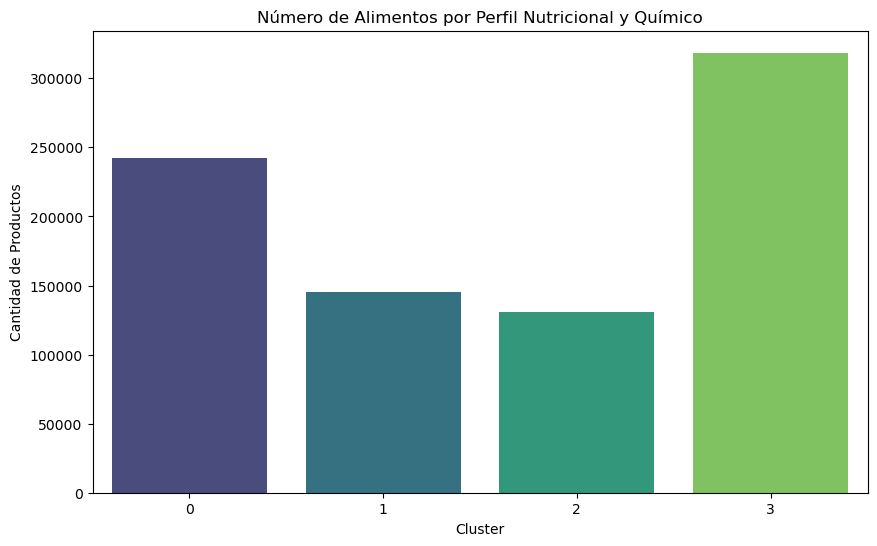

In [12]:
# 1. Realizar el conteo
conteo_clusters = df_final['cluster_alimento'].value_counts().sort_index()

# 2. Mostrar los resultados numéricos
print("Distribución de los 800k alimentos por Cluster:")
print("-" * 45)
for cluster, total in conteo_clusters.items():
    porcentaje = (total / len(df_final)) * 100
    print(f"Cluster {cluster}: {total:>7} alimentos ({porcentaje:>5.2f}%)")

# 3. Visualización rápida
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_clusters.index, y=conteo_clusters.values, palette='viridis')
plt.title('Número de Alimentos por Perfil Nutricional y Químico')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Productos')
plt.show()

In [15]:
def perfilado_binario_ocho_combinaciones(row):
    # Como ahora solo existe la Clase 0 (segura) y la Clase 1 (riesgo),
    # el riesgo químico se define únicamente si la carga de Clase 1 es mayor que 0
    tiene_riesgo_quimico = row['carga_clase_1'] > 0
    
    cluster = row['cluster_alimento']
    
    # 1. CLUSTER MORADO: Alimento Saludable (Cluster 0)
    if cluster == 0:
        if tiene_riesgo_quimico:
            return "Alimento Saludable con aditivos potencialmente de riesgo"
        else:
            return "Alimento Saludable con aditivos seguros"
            
    # 2. CLUSTER AZUL: Calórico y Sucio (Cluster 1)
    elif cluster == 1:
        if tiene_riesgo_quimico:
            return "Calórico y Sucio con aditivos de riesgo"
        else:
            return "Calórico y Sucio con aditivos seguros"
            
    # 3. CLUSTER VERDE: Falsos Amigos (Cluster 2)
    elif cluster == 2:
        if tiene_riesgo_quimico:
            return "Falso Amigo con aditivos de riesgo"
        else:
            return "Falso Amigo con aditivos seguros"
            
    # 4. CLUSTER AMARILLO: Calórico pero honesto / Bomba calórica (Cluster 3)
    elif cluster == 3:
        if tiene_riesgo_quimico:
            return "Bomba calórica con aditivos de riesgo"
        else:
            return "Bomba calórica con aditivos seguros"
            
    # Por seguridad, si existiese algún cluster no mapeado de alimentos
    return f"Cluster {cluster} - Desconocido"

# Aplicar la nueva lógica al DataFrame
df_final['categoria_final'] = df_final.apply(perfilado_binario_ocho_combinaciones, axis=1)

# Verificar la distribución de las 8 combinaciones
print("--- Distribución de las 8 Combinaciones de Alimentos ---")
print(df_final['categoria_final'].value_counts())

--- Distribución de las 8 Combinaciones de Alimentos ---
categoria_final
Bomba calórica con aditivos seguros                         177916
Alimento Saludable con aditivos seguros                     142893
Calórico y Sucio con aditivos de riesgo                     142698
Bomba calórica con aditivos de riesgo                       140591
Falso Amigo con aditivos seguros                            125672
Alimento Saludable con aditivos potencialmente de riesgo     99193
Falso Amigo con aditivos de riesgo                            5305
Calórico y Sucio con aditivos seguros                         2428
Name: count, dtype: int64


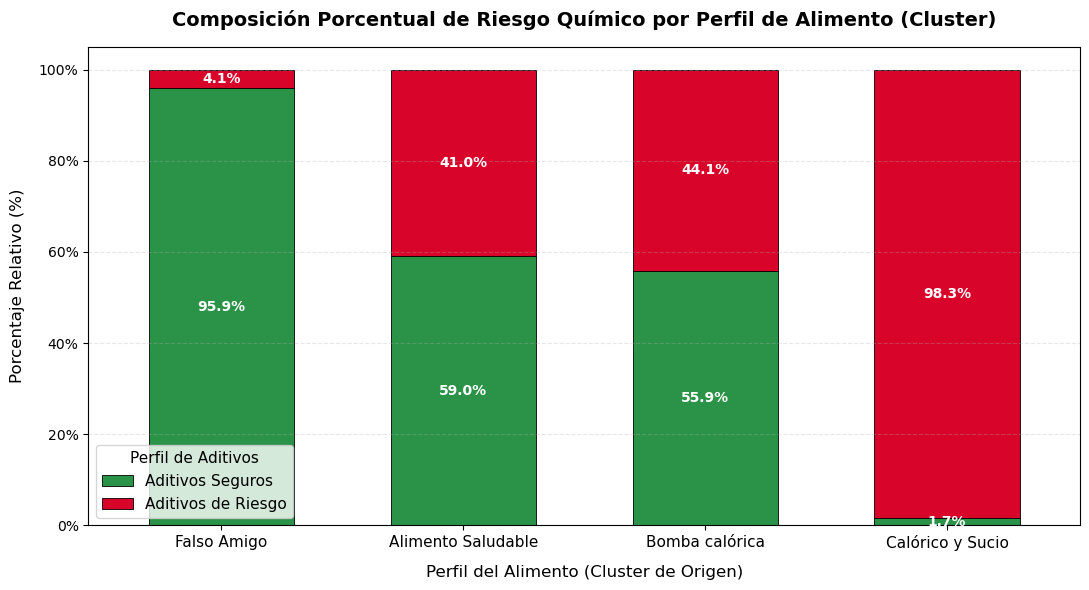

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estructurar los datos en formato de categorías y subcategorías (valores absolutos de origen)
data_combinaciones = {
    'Categoría Alimento': [
        'Bomba calórica', 'Bomba calórica', 
        'Alimento Saludable', 'Alimento Saludable',
        'Falso Amigo', 'Falso Amigo',
        'Calórico y Sucio', 'Calórico y Sucio'
    ],
    'Perfil Químico': [
        'Aditivos Seguros', 'Aditivos de Riesgo',
        'Aditivos Seguros', 'Aditivos de Riesgo',
        'Aditivos Seguros', 'Aditivos de Riesgo',
        'Aditivos Seguros', 'Aditivos de Riesgo'
    ],
    'Cantidad': [177916, 140591, 142893, 99193, 125672, 5305, 2428, 142698]
}

df_plot = pd.DataFrame(data_combinaciones)

# 2. Pivotar la tabla para cruzar los datos
df_pivot = df_plot.pivot(index='Categoría Alimento', columns='Perfil Químico', values='Cantidad')

# 3. TRANSFORMACIÓN A PORCENTAJES (Normalización por filas / clusters)
# Dividimos cada celda por la suma total de su fila y multiplicamos por 100
df_porcentajes = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

# Ordenar las categorías para mantener un criterio visual (ej: por mayor porcentaje de aditivos seguros)
df_porcentajes = df_porcentajes.sort_values(by='Aditivos Seguros', ascending=False)


# 4. Construir la visualización de barras apiladas al 100%
fig, ax = plt.subplots(figsize=(11, 6))

# Paleta de colores semántica: Verde académico y Rojo de alerta
colores_semanticos = ['#2b9348', '#d90429']

df_porcentajes.plot(
    kind='bar', 
    stacked=True,  # Apilar las barras para representar el 100%
    ax=ax, 
    color=colores_semanticos, 
    width=0.6, 
    edgecolor='black', 
    linewidth=0.6
)

# 5. AÑADIR LAS ETIQUETAS DE PORCENTAJE DENTRO DE LAS BARRAS
# Este bucle recorre cada barra dibujada para colocar el texto numérico en el centro
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    # Solo pintamos la etiqueta si el porcentaje es visible (mayor al 1%)
    if height > 1.0:
        ax.text(
            x + width/2, 
            y + height/2, 
            f'{height:.1f}%', 
            horizontalalignment='center', 
            verticalalignment='center',
            color='white', 
            weight='bold',
            fontsize=10
        )

# 6. Personalización y formateo con rigor doctoral
ax.set_title('Composición Porcentual de Riesgo Químico por Perfil de Alimento (Cluster)', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Perfil del Alimento (Cluster de Origen)', fontsize=12, labelpad=10)
ax.set_ylabel('Porcentaje Relativo (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, 105) # Espacio extra arriba para que no se corte el diseño
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Configurar el eje Y para mostrar el símbolo de porcentaje
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))

# Ajustes finales de diseño
ax.legend(title='Perfil de Aditivos', fontsize=11, title_fontsize=11, loc='lower left')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=10)

# 7. Guardado automático de la figura
plt.tight_layout()
plt.savefig('../outputs/plots/food_products/distribucion_8_combinaciones_porcentaje.png', dpi=300, bbox_inches='tight')

vale pues ya tengo toda la clasificacion finalizada, ahora necesito hacer el pipeline para hacer un streamlit donde pongas el codigo de barras y te de el alimento con la foto, nutriscore, tabla nutricional, nova score y nuestra clasificacion de alimentos y aditivos. si el alimento tiene un solo 